In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'D:\Triage Acuity Project\triagegeist\test.csv')
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score
0,TG-FZUFCRZS3,SITE-TMP-01,NURSE-0050,walk-in,7,Monday,4,spring,morning,24,...,26.7,38.5,88.8,10,10,86.9,177.2,27.7,1.032,13
1,TG-SSCOXTYI1,SITE-TMP-01,NURSE-0001,ambulance,17,Monday,3,spring,afternoon,53,...,20.6,38.9,100.0,15,9,67.0,156.2,27.5,0.827,4
2,TG-JY74ZR35D,SITE-HEL-01,NURSE-0018,ambulance,2,Monday,1,winter,night,88,...,27.7,38.8,94.7,14,6,76.3,149.4,34.2,0.694,9
3,TG-JDKD5G62X,SITE-TUR-01,NURSE-0028,walk-in,23,Saturday,3,spring,evening,59,...,14.9,36.3,99.0,15,4,103.8,172.4,35.0,0.572,0
4,TG-J1BSAAXR0,SITE-TMP-01,NURSE-0033,helicopter,16,Saturday,6,summer,afternoon,44,...,15.2,37.6,100.0,15,1,76.7,168.5,27.0,NaN,0


In [3]:
df.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode',
       'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season',
       'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type',
       'transport_origin', 'pain_location', 'mental_status_triage',
       'chief_complaint_system', 'num_prior_ed_visits_12m',
       'num_prior_admissions_12m', 'num_active_medications',
       'num_comorbidities', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'pulse_pressure', 'heart_rate',
       'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score',
       'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score'],
      dtype='object')

In [4]:
df.isnull().sum()

patient_id                    0
site_id                       0
triage_nurse_id               0
arrival_mode                  0
arrival_hour                  0
arrival_day                   0
arrival_month                 0
arrival_season                0
shift                         0
age                           0
age_group                     0
sex                           0
language                      0
insurance_type                0
transport_origin              0
pain_location                 0
mental_status_triage          0
chief_complaint_system        0
num_prior_ed_visits_12m       0
num_prior_admissions_12m      0
num_active_medications        0
num_comorbidities             0
systolic_bp                 962
diastolic_bp                962
mean_arterial_pressure      962
pulse_pressure              962
heart_rate                    0
respiratory_rate            752
temperature_c               106
spo2                          0
gcs_total                     0
pain_sco

In [5]:
df['site_id'].unique()

array(['SITE-TMP-01', 'SITE-HEL-01', 'SITE-TUR-01', 'SITE-HEL-02',
       'SITE-OUL-01'], dtype=object)

In [6]:
# encoding side_id
site = {
    'SITE-TMP-01' : 1,
    'SITE-HEL-01' : 2,
    'SITE-HEL-02' : 3,
    'SITE-TUR-01' : 4,
    'SITE-OUL-01' : 5
}

df['site_id'] = df['site_id'].map(site)

In [7]:
df['triage_nurse_id'].unique()

array(['NURSE-0050', 'NURSE-0001', 'NURSE-0018', 'NURSE-0028',
       'NURSE-0033', 'NURSE-0029', 'NURSE-0003', 'NURSE-0047',
       'NURSE-0040', 'NURSE-0004', 'NURSE-0023', 'NURSE-0027',
       'NURSE-0006', 'NURSE-0020', 'NURSE-0036', 'NURSE-0049',
       'NURSE-0042', 'NURSE-0007', 'NURSE-0019', 'NURSE-0016',
       'NURSE-0044', 'NURSE-0045', 'NURSE-0012', 'NURSE-0034',
       'NURSE-0009', 'NURSE-0030', 'NURSE-0013', 'NURSE-0015',
       'NURSE-0035', 'NURSE-0039', 'NURSE-0022', 'NURSE-0008',
       'NURSE-0041', 'NURSE-0011', 'NURSE-0024', 'NURSE-0038',
       'NURSE-0037', 'NURSE-0021', 'NURSE-0031', 'NURSE-0010',
       'NURSE-0026', 'NURSE-0014', 'NURSE-0017', 'NURSE-0002',
       'NURSE-0043', 'NURSE-0032', 'NURSE-0025', 'NURSE-0005',
       'NURSE-0046', 'NURSE-0048'], dtype=object)

In [8]:
## frequency encoding the nurses ,  because behavior of nurses is a key feature for acuity
freq = df['triage_nurse_id'].value_counts().to_dict()
df['triage_nurse_id'] = df['triage_nurse_id'].map(freq)

In [9]:
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score
0,TG-FZUFCRZS3,1,359,walk-in,7,Monday,4,spring,morning,24,...,26.7,38.5,88.8,10,10,86.9,177.2,27.7,1.032,13
1,TG-SSCOXTYI1,1,393,ambulance,17,Monday,3,spring,afternoon,53,...,20.6,38.9,100.0,15,9,67.0,156.2,27.5,0.827,4
2,TG-JY74ZR35D,2,379,ambulance,2,Monday,1,winter,night,88,...,27.7,38.8,94.7,14,6,76.3,149.4,34.2,0.694,9
3,TG-JDKD5G62X,4,367,walk-in,23,Saturday,3,spring,evening,59,...,14.9,36.3,99.0,15,4,103.8,172.4,35.0,0.572,0
4,TG-J1BSAAXR0,1,401,helicopter,16,Saturday,6,summer,afternoon,44,...,15.2,37.6,100.0,15,1,76.7,168.5,27.0,NaN,0


In [10]:
df['arrival_mode'].unique()

array(['walk-in', 'ambulance', 'helicopter', 'brought_by_family',
       'police', 'transfer'], dtype=object)

In [11]:
# manual encoding arrival_mode
arrival = {
    'walk-in':1,
    'police':2,
    'ambulance':3,
    'transfer':4,
    'helicopter':5,
    'brought_by_family':6,
}
df['arrival_mode'] = df['arrival_mode'].map(arrival)

In [12]:
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score
0,TG-FZUFCRZS3,1,359,1,7,Monday,4,spring,morning,24,...,26.7,38.5,88.8,10,10,86.9,177.2,27.7,1.032,13
1,TG-SSCOXTYI1,1,393,3,17,Monday,3,spring,afternoon,53,...,20.6,38.9,100.0,15,9,67.0,156.2,27.5,0.827,4
2,TG-JY74ZR35D,2,379,3,2,Monday,1,winter,night,88,...,27.7,38.8,94.7,14,6,76.3,149.4,34.2,0.694,9
3,TG-JDKD5G62X,4,367,1,23,Saturday,3,spring,evening,59,...,14.9,36.3,99.0,15,4,103.8,172.4,35.0,0.572,0
4,TG-J1BSAAXR0,1,401,5,16,Saturday,6,summer,afternoon,44,...,15.2,37.6,100.0,15,1,76.7,168.5,27.0,NaN,0


In [13]:
df['arrival_day'].unique()

array(['Monday', 'Saturday', 'Tuesday', 'Friday', 'Thursday', 'Sunday',
       'Wednesday'], dtype=object)

In [14]:
## Cyclic encoding for our week days

day_map = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

df['day_num'] = df['arrival_day'].map(day_map)

In [15]:
## Applying sin , cos transformations

df['day_sin'] = np.sin(2 * np.pi * df['day_num'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_num'] / 7)

In [16]:
df['day_sin']

0        0.000000
1        0.000000
2        0.000000
3       -0.974928
4       -0.974928
           ...   
19995    0.974928
19996   -0.781831
19997   -0.433884
19998    0.000000
19999    0.974928
Name: day_sin, Length: 20000, dtype: float64

In [17]:
df['day_cos']

0        1.000000
1        1.000000
2        1.000000
3       -0.222521
4       -0.222521
           ...   
19995   -0.222521
19996    0.623490
19997   -0.900969
19998    1.000000
19999   -0.222521
Name: day_cos, Length: 20000, dtype: float64

In [18]:
### why we did cyclic encoding instead of manual encoding , becoz in that case model thinks sunday=0 is > saturday=6

In [19]:
# now we remove df['arrival_day] and day_num

df = df.drop(['arrival_day' , 'day_num'] , axis = 1)

In [20]:
df['arrival_season'].unique()

array(['spring', 'winter', 'summer', 'autumn'], dtype=object)

In [22]:
# we see all seasons are identical , so we drop this feature
df = df.drop('arrival_season' , axis = 1)

In [23]:
df.head()
df.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode',
       'arrival_hour', 'arrival_month', 'shift', 'age', 'age_group', 'sex',
       'language', 'insurance_type', 'transport_origin', 'pain_location',
       'mental_status_triage', 'chief_complaint_system',
       'num_prior_ed_visits_12m', 'num_prior_admissions_12m',
       'num_active_medications', 'num_comorbidities', 'systolic_bp',
       'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure',
       'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total',
       'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index',
       'news2_score', 'day_sin', 'day_cos'],
      dtype='object')

In [24]:
# so we drop thius feature too
df = df.drop('arrival_month' , axis=1)

In [25]:
### encoding done till arrival_mode , 
# have to start from arrival_hour

df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,shift,age,age_group,sex,language,...,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,day_sin,day_cos
0,TG-FZUFCRZS3,1,359,1,7,morning,24,young_adult,M,English,...,88.8,10,10,86.9,177.2,27.7,1.032,13,0.000000,1.000000
1,TG-SSCOXTYI1,1,393,3,17,afternoon,53,middle_aged,F,Russian,...,100.0,15,9,67.0,156.2,27.5,0.827,4,0.000000,1.000000
2,TG-JY74ZR35D,2,379,3,2,night,88,elderly,F,Finnish,...,94.7,14,6,76.3,149.4,34.2,0.694,9,0.000000,1.000000
3,TG-JDKD5G62X,4,367,1,23,evening,59,middle_aged,M,Swedish,...,99.0,15,4,103.8,172.4,35.0,0.572,0,-0.974928,-0.222521
4,TG-J1BSAAXR0,1,401,5,16,afternoon,44,middle_aged,F,Finnish,...,100.0,15,1,76.7,168.5,27.0,NaN,0,-0.974928,-0.222521


In [26]:
df = df.drop('arrival_hour' , axis = 1)

In [27]:
df = df.drop('shift' , axis = 1)

In [28]:
### observing age group
num_age_groups = df['age_group'].value_counts()
num_age_groups

age_group
middle_aged    6890
young_adult    6185
elderly        5342
pediatric      1583
Name: count, dtype: int64

In [29]:
index_age_groups = df['age_group'].value_counts().index
index_age_groups

Index(['middle_aged', 'young_adult', 'elderly', 'pediatric'], dtype='object', name='age_group')

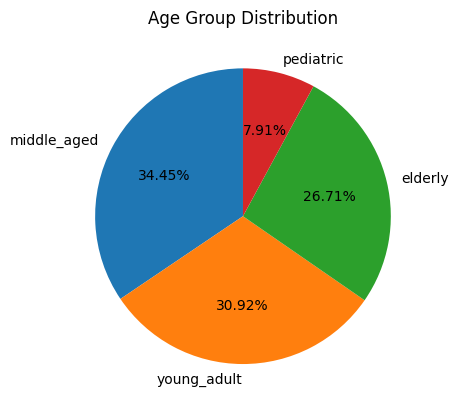

In [30]:
plt.pie(
    num_age_groups , 
    labels = index_age_groups , 
    autopct = '%1.2f%%' , 
    startangle=90
)
plt.title('Age Group Distribution')
plt.show()

In [32]:
## encoding age group
df['age_group'] = df['age_group'].map({
    'pediatric' : 0,
    'young_adult' : 1,
    'middle_aged' : 2,
    'elderly' : 3
})

In [33]:
# cHECKING language
df['language'].unique()

array(['English', 'Russian', 'Finnish', 'Swedish', 'Estonian', 'Other',
       'Arabic', 'Somali'], dtype=object)

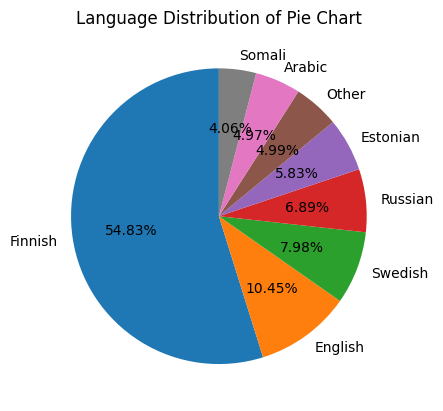

In [34]:
num_lang = df['language'].value_counts()
num_lang

index_lang = df['language'].value_counts().index
index_lang


plt.pie(
    num_lang , 
    labels = index_lang , 
    autopct = '%1.2f%%' , 
    startangle=90
)
plt.title('Language Distribution of Pie Chart')
plt.show()

In [35]:
# removing language column
df = df.drop('language' , axis=1)
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,age,age_group,sex,insurance_type,transport_origin,pain_location,...,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,day_sin,day_cos
0,TG-FZUFCRZS3,1,359,1,24,1,M,public,public_space,none,...,88.8,10,10,86.9,177.2,27.7,1.032,13,0.000000,1.000000
1,TG-SSCOXTYI1,1,393,3,53,2,F,private,nursing_home,pelvis,...,100.0,15,9,67.0,156.2,27.5,0.827,4,0.000000,1.000000
2,TG-JY74ZR35D,2,379,3,88,3,F,public,nursing_home,multiple,...,94.7,14,6,76.3,149.4,34.2,0.694,9,0.000000,1.000000
3,TG-JDKD5G62X,4,367,1,59,2,M,unknown,workplace,abdomen,...,99.0,15,4,103.8,172.4,35.0,0.572,0,-0.974928,-0.222521
4,TG-J1BSAAXR0,1,401,5,44,2,F,private,school,multiple,...,100.0,15,1,76.7,168.5,27.0,NaN,0,-0.974928,-0.222521


In [36]:
# dropping sex column as it's acuity is same for male and female
df = df.drop('sex' , axis = 1)

In [37]:
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,age,age_group,insurance_type,transport_origin,pain_location,mental_status_triage,...,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,day_sin,day_cos
0,TG-FZUFCRZS3,1,359,1,24,1,public,public_space,none,confused,...,88.8,10,10,86.9,177.2,27.7,1.032,13,0.000000,1.000000
1,TG-SSCOXTYI1,1,393,3,53,2,private,nursing_home,pelvis,alert,...,100.0,15,9,67.0,156.2,27.5,0.827,4,0.000000,1.000000
2,TG-JY74ZR35D,2,379,3,88,3,public,nursing_home,multiple,agitated,...,94.7,14,6,76.3,149.4,34.2,0.694,9,0.000000,1.000000
3,TG-JDKD5G62X,4,367,1,59,2,unknown,workplace,abdomen,alert,...,99.0,15,4,103.8,172.4,35.0,0.572,0,-0.974928,-0.222521
4,TG-J1BSAAXR0,1,401,5,44,2,private,school,multiple,alert,...,100.0,15,1,76.7,168.5,27.0,NaN,0,-0.974928,-0.222521


In [38]:
# in the above figure we see acuity 3 is dominating everwhere , so 'insurance_type' is a weak feature
# dropping it
df = df.drop('insurance_type' , axis = 1)

In [39]:
df = df.drop('transport_origin' , axis = 1)

In [40]:
df['pain_location'].unique()

array(['none', 'pelvis', 'multiple', 'abdomen', 'back', 'unknown',
       'extremity', 'chest', 'head'], dtype=object)

In [41]:
### as this is not a real dataset , so above distribution follows a similar patter , but still we dont remove it , because pain location is an important factor for triage acuity

# encoding pain location using one hot encoding

# first merging unknown and none
df['pain_location'] = df['pain_location'].replace({
    'unknown': 'other',
    'none': 'other'
})

df = pd.get_dummies(df , columns = ['pain_location'] , drop_first = True)

In [42]:
## Mental status triage is a very usewfull feature fpr determining triage acuity , so we keep it.

# alert < drowsy < confused < agitated < unresponsive

# ordinal encoding it
mental_status = {
    'alert' : 0,
    'drowsy' : 1,
    'confused' : 2,
    'agitated' : 3,
    'unresponsive' : 4
}
df['mental_status_triage'] = df['mental_status_triage'].map(mental_status)

In [43]:
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,age,age_group,mental_status_triage,chief_complaint_system,num_prior_ed_visits_12m,num_prior_admissions_12m,...,news2_score,day_sin,day_cos,pain_location_back,pain_location_chest,pain_location_extremity,pain_location_head,pain_location_multiple,pain_location_other,pain_location_pelvis
0,TG-FZUFCRZS3,1,359,1,24,1,2,musculoskeletal,2,2,...,13,0.000000,1.000000,False,False,False,False,False,True,False
1,TG-SSCOXTYI1,1,393,3,53,2,0,ENT,0,0,...,4,0.000000,1.000000,False,False,False,False,False,False,True
2,TG-JY74ZR35D,2,379,3,88,3,3,gastrointestinal,4,0,...,9,0.000000,1.000000,False,False,False,False,True,False,False
3,TG-JDKD5G62X,4,367,1,59,2,0,dermatological,2,1,...,0,-0.974928,-0.222521,False,False,False,False,False,False,False
4,TG-J1BSAAXR0,1,401,5,44,2,0,endocrine,0,0,...,0,-0.974928,-0.222521,False,False,False,False,True,False,False


In [45]:
df['chief_complaint_system'].unique()

array(['musculoskeletal', 'ENT', 'gastrointestinal', 'dermatological',
       'endocrine', 'cardiovascular', 'trauma', 'respiratory', 'other',
       'genitourinary', 'ophthalmic', 'psychiatric', 'neurological',
       'infectious'], dtype=object)

In [46]:
# 3 grouping imp ones to avoid noise

df['chief_complaint_system'] = df['chief_complaint_system'].replace({
    'neurological' : 'critical',
    'trauma' : 'critical',
    'respiratory' : 'critical',
    'cardiovascular' : 'crticial',


    'gastrointestinal' : 'moderate',
    'infectious' : 'moderate',
    'endocrine' : 'moderate',

    'dermatological' : 'mild',
    'ophthalmic' : 'mild',
    'ENT' : 'mild',

    'psychiatric' : 'special',
    'genitourunary' : 'special',
    'musculoskeletal' : 'special',
    'other' : 'special'

})

In [47]:
df = pd.get_dummies(df , columns = ['chief_complaint_system'] , drop_first = True)

In [48]:
df.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'age',
       'age_group', 'mental_status_triage', 'num_prior_ed_visits_12m',
       'num_prior_admissions_12m', 'num_active_medications',
       'num_comorbidities', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'pulse_pressure', 'heart_rate',
       'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score',
       'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score',
       'day_sin', 'day_cos', 'pain_location_back', 'pain_location_chest',
       'pain_location_extremity', 'pain_location_head',
       'pain_location_multiple', 'pain_location_other', 'pain_location_pelvis',
       'chief_complaint_system_crticial',
       'chief_complaint_system_genitourinary', 'chief_complaint_system_mild',
       'chief_complaint_system_moderate', 'chief_complaint_system_special'],
      dtype='object')

In [49]:
cat_cols = df.select_dtypes(include = ['object' , 'string' , 'category']).columns
cat_cols

Index(['patient_id'], dtype='object')

In [51]:
pd.set_option('display.max_columns' , None)

In [52]:
df.head(10)

,patient_id,site_id,triage_nurse_id,arrival_mode,age,age_group,mental_status_triage,num_prior_ed_visits_12m,num_prior_admissions_12m,num_active_medications,num_comorbidities,systolic_bp,diastolic_bp,mean_arterial_pressure,pulse_pressure,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,day_sin,day_cos,pain_location_back,pain_location_chest,pain_location_extremity,pain_location_head,pain_location_multiple,pain_location_other,pain_location_pelvis,chief_complaint_system_crticial,chief_complaint_system_genitourinary,chief_complaint_system_mild,chief_complaint_system_moderate,chief_complaint_system_special
0,TG-FZUFCRZS3,1,359,1,24,1,2,2,2,4,4,73.0,77.9,76.3,-4.9,75.3,26.7,38.5,88.8,10,10,86.9,177.2,27.7,1.032,13,0.000000,1.000000,False,False,False,False,False,True,False,False,False,False,False,True
1,TG-SSCOXTYI1,1,393,3,53,2,0,0,0,4,6,112.1,70.0,84.0,42.1,92.7,20.6,38.9,100.0,15,9,67.0,156.2,27.5,0.827,4,0.000000,1.000000,False,False,False,False,False,False,True,False,False,True,False,False
2,TG-JY74ZR35D,2,379,3,88,3,3,4,0,6,6,131.2,70.8,90.9,60.4,91.1,27.7,38.8,94.7,14,6,76.3,149.4,34.2,0.694,9,0.000000,1.000000,False,False,False,False,True,False,False,False,False,False,True,False
3,TG-JDKD5G62X,4,367,1,59,2,0,2,1,9,10,136.9,78.2,97.8,58.7,78.3,14.9,36.3,99.0,15,4,103.8,172.4,35.0,0.572,0,-0.974928,-0.222521,False,False,False,False,False,False,False,False,False,True,False,False
4,TG-J1BSAAXR0,1,401,5,44,2,0,0,0,2,4,NaN,NaN,NaN,NaN,65.5,15.2,37.6,100.0,15,1,76.7,168.5,27.0,NaN,0,-0.974928,-0.222521,False,False,False,False,True,False,False,False,False,False,True,False
5,TG-5YERUAA5X,1,449,1,53,2,0,0,0,7,3,153.0,70.5,98.0,82.5,94.3,17.4,37.2,98.7,15,-1,70.6,172.4,23.7,0.616,1,0.781831,0.623490,True,False,False,False,False,False,False,False,False,False,True,False
6,TG-IVU18ZJCF,2,395,3,21,1,1,1,1,3,6,85.1,62.5,70.0,22.6,151.1,16.5,38.5,86.5,13,9,111.6,174.6,36.6,1.776,13,-0.433884,-0.900969,False,False,False,False,True,False,False,True,False,False,False,False
7,TG-K5XYMWTCG,3,374,3,81,3,4,3,2,7,10,81.2,64.1,69.8,17.1,91.7,27.6,37.1,90.5,11,7,68.8,179.4,21.4,1.129,13,-0.974928,-0.222521,False,False,False,False,True,False,False,False,False,False,True,False
8,TG-RCAR2TLEI,3,431,6,78,3,1,1,0,7,8,142.6,93.3,109.7,49.3,80.4,19.1,37.6,99.5,15,6,67.2,173.5,22.3,0.564,0,-0.974928,-0.222521,False,False,False,False,False,True,False,False,False,False,False,False
9,TG-YNDUR0KGO,2,404,3,42,2,2,1,0,3,6,165.7,112.3,130.1,53.4,87.3,13.0,36.3,96.9,15,6,84.0,167.9,29.8,0.527,0,0.433884,-0.900969,False,False,False,False,False,True,False,False,False,False,False,True


#### Now coming to missing values

In [53]:
df.isna().sum()[df.isna().sum() > 0]

systolic_bp               962
diastolic_bp              962
mean_arterial_pressure    962
pulse_pressure            962
respiratory_rate          752
temperature_c             106
shock_index               962
dtype: int64

In [55]:
cols = [
    'systolic_bp',
    'diastolic_bp',
    'mean_arterial_pressure',
    'pulse_pressure',
    'respiratory_rate',
    'temperature_c',
    'shock_index'
]

df_selected = df[cols]

df_selected.head()

,systolic_bp,diastolic_bp,mean_arterial_pressure,pulse_pressure,respiratory_rate,temperature_c,shock_index
0,73.0,77.9,76.3,-4.9,26.7,38.5,1.032
1,112.1,70.0,84.0,42.1,20.6,38.9,0.827
2,131.2,70.8,90.9,60.4,27.7,38.8,0.694
3,136.9,78.2,97.8,58.7,14.9,36.3,0.572
4,NaN,NaN,NaN,NaN,15.2,37.6,NaN


In [56]:
for col in cols:
    df[col + '_missing'] = df[col].isna().astype(int)

In [57]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [58]:
df.isna().sum().sum()

0

In [59]:
df.isnull().sum()

patient_id                              0
site_id                                 0
triage_nurse_id                         0
arrival_mode                            0
age                                     0
age_group                               0
mental_status_triage                    0
num_prior_ed_visits_12m                 0
num_prior_admissions_12m                0
num_active_medications                  0
num_comorbidities                       0
systolic_bp                             0
diastolic_bp                            0
mean_arterial_pressure                  0
pulse_pressure                          0
heart_rate                              0
respiratory_rate                        0
temperature_c                           0
spo2                                    0
gcs_total                               0
pain_score                              0
weight_kg                               0
height_cm                               0
bmi                               

In [60]:
df.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,age,age_group,mental_status_triage,num_prior_ed_visits_12m,num_prior_admissions_12m,num_active_medications,num_comorbidities,systolic_bp,diastolic_bp,mean_arterial_pressure,pulse_pressure,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,day_sin,day_cos,pain_location_back,pain_location_chest,pain_location_extremity,pain_location_head,pain_location_multiple,pain_location_other,pain_location_pelvis,chief_complaint_system_crticial,chief_complaint_system_genitourinary,chief_complaint_system_mild,chief_complaint_system_moderate,chief_complaint_system_special,systolic_bp_missing,diastolic_bp_missing,mean_arterial_pressure_missing,pulse_pressure_missing,respiratory_rate_missing,temperature_c_missing,shock_index_missing
0,TG-FZUFCRZS3,1,359,1,24,1,2,2,2,4,4,73.0,77.9,76.3,-4.9,75.3,26.7,38.5,88.8,10,10,86.9,177.2,27.7,1.032,13,0.000000,1.000000,False,False,False,False,False,True,False,False,False,False,False,True,0,0,0,0,0,0,0
1,TG-SSCOXTYI1,1,393,3,53,2,0,0,0,4,6,112.1,70.0,84.0,42.1,92.7,20.6,38.9,100.0,15,9,67.0,156.2,27.5,0.827,4,0.000000,1.000000,False,False,False,False,False,False,True,False,False,True,False,False,0,0,0,0,0,0,0
2,TG-JY74ZR35D,2,379,3,88,3,3,4,0,6,6,131.2,70.8,90.9,60.4,91.1,27.7,38.8,94.7,14,6,76.3,149.4,34.2,0.694,9,0.000000,1.000000,False,False,False,False,True,False,False,False,False,False,True,False,0,0,0,0,0,0,0
3,TG-JDKD5G62X,4,367,1,59,2,0,2,1,9,10,136.9,78.2,97.8,58.7,78.3,14.9,36.3,99.0,15,4,103.8,172.4,35.0,0.572,0,-0.974928,-0.222521,False,False,False,False,False,False,False,False,False,True,False,False,0,0,0,0,0,0,0
4,TG-J1BSAAXR0,1,401,5,44,2,0,0,0,2,4,123.2,75.6,92.0,47.2,65.5,15.2,37.6,100.0,15,1,76.7,168.5,27.0,0.724,0,-0.974928,-0.222521,False,False,False,False,True,False,False,False,False,False,True,False,1,1,1,1,0,0,1


In [62]:
df.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'age',
       'age_group', 'mental_status_triage', 'num_prior_ed_visits_12m',
       'num_prior_admissions_12m', 'num_active_medications',
       'num_comorbidities', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'pulse_pressure', 'heart_rate',
       'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score',
       'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score',
       'day_sin', 'day_cos', 'pain_location_back', 'pain_location_chest',
       'pain_location_extremity', 'pain_location_head',
       'pain_location_multiple', 'pain_location_other', 'pain_location_pelvis',
       'chief_complaint_system_crticial',
       'chief_complaint_system_genitourinary', 'chief_complaint_system_mild',
       'chief_complaint_system_moderate', 'chief_complaint_system_special',
       'systolic_bp_missing', 'diastolic_bp_missing',
       'mean_arterial_pressure_missing', 'pulse_pressure_miss

In [61]:
df.shape

(20000, 47)

In [63]:
df.to_csv('test_set.csv' , index = False)

In [64]:
df.duplicated().sum()  # means no duplicate value

0